#### Dataset Information

timestamp: Real-time data capture in minute-level intervals. machine_id: Unique identifier for each machine. machine_type: Type of production equipment. temperature: Machine temperature (°C). vibration_level: Vibration intensity indicating potential wear or misalignment. power_consumption: Energy usage in kilowatts (kW). pressure: System pressure in pascals (Pa). material_flow_rate: Speed of material movement through the system. cycle_time: Duration of one production cycle (seconds). error_rate: Proportion of defective products in the cycle. downtime: Machine inactivity time (minutes). maintenance_flag: Indicates whether maintenance is required (0 = No, 1 = Yes). efficiency_score: Overall production efficiency (0 to 100). production_status: Binary indicator for production efficiency (0 = Inefficient, 1 = Efficient).

## Import Libraries

In [151]:
# Data Manupulation Libraries
import pandas as pd
import numpy as np

# Data Visulization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Extraction Libraries
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine Learning Libraries
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
!pip install --upgrade xgboost scikit-learn
from xgboost import XGBRegressor
from sklearn.svm import SVR

# Model Evluation Libraries
from scipy.stats import shapiro, normaltest, kstest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Pickel file Libraries
import pickle 

## Import Dataset

In [152]:
df = pd.read_csv("C:/Users/Suyash Kadu/Desktop/CODING/NOTES/Machine Learning/Production System Dataset.csv")
df

,timestamp,machine_id,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score,production_status
0,2025-03-10 08:00:00,M003,Welder,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0,11.675410,0
1,2025-03-10 08:01:00,M004,Conveyor,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0,3.292706,0
2,2025-03-10 08:02:00,M001,Drill,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0,5.762582,0
3,2025-03-10 08:03:00,M003,Conveyor,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0,0.851911,0
4,2025-03-10 08:04:00,M003,CNC,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0,18.663902,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2455,2025-03-12 00:55:00,M001,Conveyor,80.585617,1.744735,14.463169,5.034138,20.826884,113.009590,0.652834,0,0,34.716573,0
2456,2025-03-12 00:56:00,M003,Drill,78.171483,2.732367,19.990335,4.971981,18.291071,132.987186,0.988201,0,0,1.179945,0
2457,2025-03-12 00:57:00,M003,Welder,78.782847,2.131138,19.874735,5.290168,22.551457,114.350925,0.847650,0,0,15.234984,0
2458,2025-03-12 00:58:00,M001,Drill,77.939129,2.027617,19.660323,4.924919,22.706616,117.406875,0.807874,0,0,19.212551,0


In [153]:
df.shape

(2460, 14)

In [154]:
df.size

34440

In [155]:
df.describe()

,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score,production_status
count,2411.000000,2404.000000,2405.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.0
mean,77.938602,2.230957,18.422577,4.993933,20.032925,120.071115,0.794854,12.313008,0.059350,15.577832,0.0
std,3.944714,1.117706,2.669908,0.391494,1.511022,5.057995,0.085257,18.408838,0.236326,10.763130,0.0
min,66.136665,1.048872,10.326689,3.431040,15.376157,101.823999,0.540933,0.000000,0.000000,0.000000,0.0
25%,75.240313,1.806224,16.741559,4.732438,19.017601,116.624522,0.735993,0.000000,0.000000,5.760614,0.0
50%,77.734034,2.005956,18.159299,4.992426,20.031692,120.089570,0.789355,0.000000,0.000000,17.017636,0.0
75%,80.165885,2.230489,19.699169,5.251234,21.050319,123.567379,0.842145,36.000000,0.000000,23.980193,0.0
max,94.569177,9.109769,34.368410,6.351107,25.143366,142.395421,1.000000,50.000000,1.000000,45.906702,0.0


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           2460 non-null   object 
 1   machine_id          2460 non-null   object 
 2   machine_type        2460 non-null   object 
 3   temperature         2411 non-null   float64
 4   vibration_level     2404 non-null   float64
 5   power_consumption   2405 non-null   float64
 6   pressure            2460 non-null   float64
 7   material_flow_rate  2460 non-null   float64
 8   cycle_time          2460 non-null   float64
 9   error_rate          2460 non-null   float64
 10  downtime            2460 non-null   int64  
 11  maintenance_flag    2460 non-null   int64  
 12  efficiency_score    2460 non-null   float64
 13  production_status   2460 non-null   int64  
dtypes: float64(8), int64(3), object(3)
memory usage: 269.2+ KB


In [157]:
df.isna().sum()

timestamp              0
machine_id             0
machine_type           0
temperature           49
vibration_level       56
power_consumption     55
pressure               0
material_flow_rate     0
cycle_time             0
error_rate             0
downtime               0
maintenance_flag       0
efficiency_score       0
production_status      0
dtype: int64

In [158]:
df.duplicated().sum()

np.int64(0)

## EDA

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           2460 non-null   object 
 1   machine_id          2460 non-null   object 
 2   machine_type        2460 non-null   object 
 3   temperature         2411 non-null   float64
 4   vibration_level     2404 non-null   float64
 5   power_consumption   2405 non-null   float64
 6   pressure            2460 non-null   float64
 7   material_flow_rate  2460 non-null   float64
 8   cycle_time          2460 non-null   float64
 9   error_rate          2460 non-null   float64
 10  downtime            2460 non-null   int64  
 11  maintenance_flag    2460 non-null   int64  
 12  efficiency_score    2460 non-null   float64
 13  production_status   2460 non-null   int64  
dtypes: float64(8), int64(3), object(3)
memory usage: 269.2+ KB


In [160]:
df.isna().sum()

timestamp              0
machine_id             0
machine_type           0
temperature           49
vibration_level       56
power_consumption     55
pressure               0
material_flow_rate     0
cycle_time             0
error_rate             0
downtime               0
maintenance_flag       0
efficiency_score       0
production_status      0
dtype: int64

In [161]:
df.dropna(inplace=True)

In [162]:
df.isna().sum()

timestamp             0
machine_id            0
machine_type          0
temperature           0
vibration_level       0
power_consumption     0
pressure              0
material_flow_rate    0
cycle_time            0
error_rate            0
downtime              0
maintenance_flag      0
efficiency_score      0
production_status     0
dtype: int64

In [163]:
df.shape

(2303, 14)

In [164]:
df["machine_type"].duplicated().sum()

np.int64(2299)

In [165]:
df["machine_id"].duplicated().sum()

np.int64(2299)

In [166]:
df

,timestamp,machine_id,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score,production_status
0,2025-03-10 08:00:00,M003,Welder,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0,11.675410,0
1,2025-03-10 08:01:00,M004,Conveyor,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0,3.292706,0
2,2025-03-10 08:02:00,M001,Drill,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0,5.762582,0
3,2025-03-10 08:03:00,M003,Conveyor,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0,0.851911,0
4,2025-03-10 08:04:00,M003,CNC,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0,18.663902,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2455,2025-03-12 00:55:00,M001,Conveyor,80.585617,1.744735,14.463169,5.034138,20.826884,113.009590,0.652834,0,0,34.716573,0
2456,2025-03-12 00:56:00,M003,Drill,78.171483,2.732367,19.990335,4.971981,18.291071,132.987186,0.988201,0,0,1.179945,0
2457,2025-03-12 00:57:00,M003,Welder,78.782847,2.131138,19.874735,5.290168,22.551457,114.350925,0.847650,0,0,15.234984,0
2458,2025-03-12 00:58:00,M001,Drill,77.939129,2.027617,19.660323,4.924919,22.706616,117.406875,0.807874,0,0,19.212551,0


## Column Data 

#### Continuous Data = temperature, vibration_level, power_consumption, pressure, material_flow_rate, cycle_time, error_rate, downtime, efficiency_score

#### Categorical Data = machine_id, machine_type, maintenance_flag, production_status

## Univariate Analysis

In [167]:
def Univariate_Continuous_Data_Analysis(col):
    print("---"*45)

    a = pd.DataFrame({
        "Mean": [df[col].mean()],
        "Median": [df[col].median()],
        "Variance": [df[col].var()],
        "Standard Deviation": [df[col].std()],
        "Range": [(df[col].max()) - (df[col].min())]
    })

    print(a)
    print("---"*45)

    sns.histplot(df[col], kde = True, color="orange")
    plt.show()
    

---------- Column Name: TEMPERATURE ----------

---------------------------------------------------------------------------------------------------------------------------------------
        Mean     Median   Variance  Standard Deviation     Range
0  77.920389  77.723363  15.411875            3.925796  28.41586
---------------------------------------------------------------------------------------------------------------------------------------


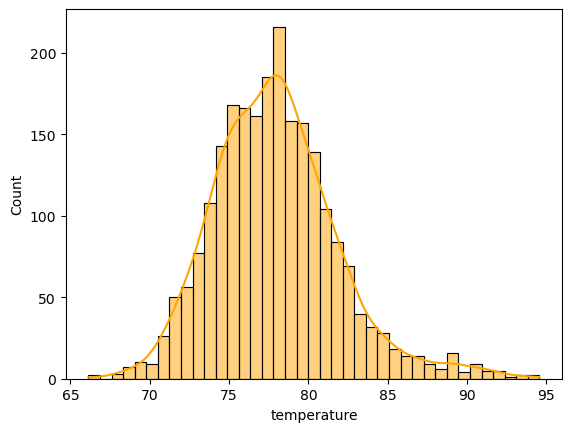

---------- Column Name: VIBRATION_LEVEL ----------

---------------------------------------------------------------------------------------------------------------------------------------
       Mean    Median  Variance  Standard Deviation     Range
0  2.226426  2.004705  1.229406            1.108786  8.060897
---------------------------------------------------------------------------------------------------------------------------------------


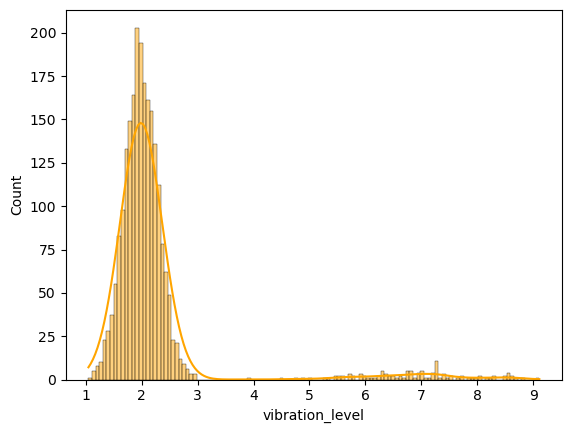

---------- Column Name: POWER_CONSUMPTION ----------

---------------------------------------------------------------------------------------------------------------------------------------
        Mean     Median  Variance  Standard Deviation     Range
0  18.413512  18.156015  7.005049            2.646705  23.74514
---------------------------------------------------------------------------------------------------------------------------------------


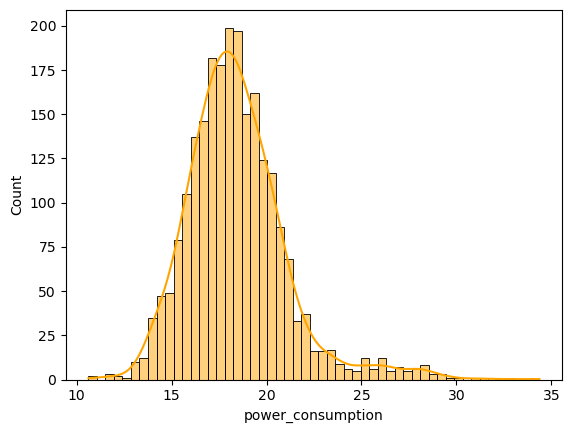

---------- Column Name: PRESSURE ----------

---------------------------------------------------------------------------------------------------------------------------------------
      Mean    Median  Variance  Standard Deviation     Range
0  4.99431  4.992746  0.153511            0.391805  2.920067
---------------------------------------------------------------------------------------------------------------------------------------


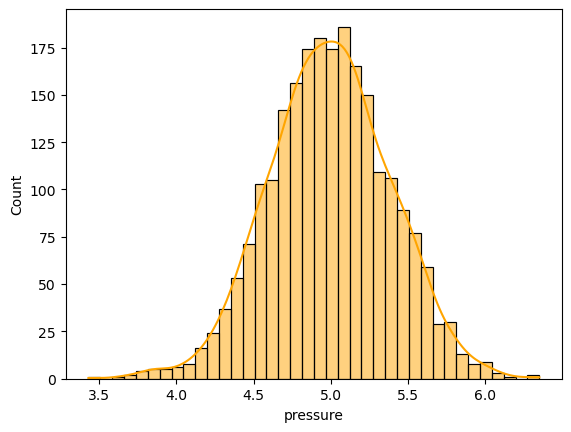

---------- Column Name: MATERIAL_FLOW_RATE ----------

---------------------------------------------------------------------------------------------------------------------------------------
        Mean     Median  Variance  Standard Deviation     Range
0  20.025513  20.030041  2.301835             1.51718  9.767209
---------------------------------------------------------------------------------------------------------------------------------------


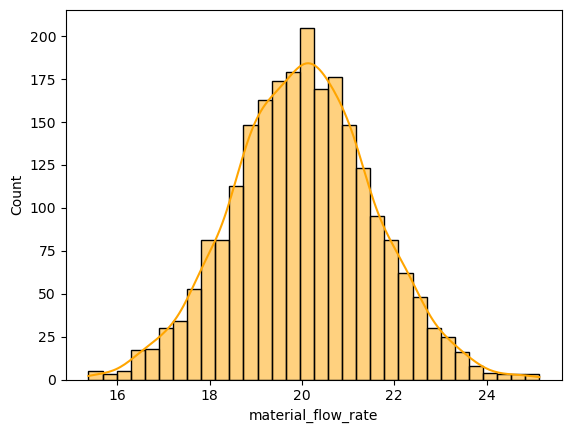

---------- Column Name: CYCLE_TIME ----------

---------------------------------------------------------------------------------------------------------------------------------------
         Mean      Median   Variance  Standard Deviation      Range
0  120.048745  120.085344  25.720387            5.071527  40.571422
---------------------------------------------------------------------------------------------------------------------------------------


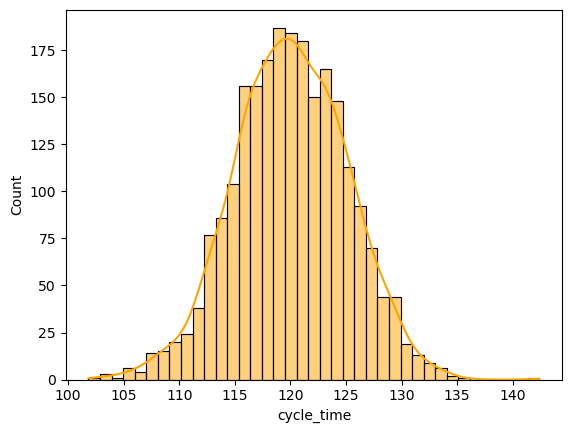

---------- Column Name: ERROR_RATE ----------

---------------------------------------------------------------------------------------------------------------------------------------
       Mean    Median  Variance  Standard Deviation     Range
0  0.794587  0.788974  0.007196             0.08483  0.459067
---------------------------------------------------------------------------------------------------------------------------------------


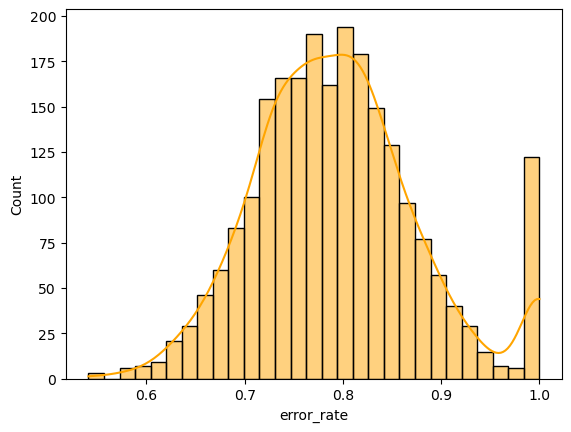

---------- Column Name: DOWNTIME ----------

---------------------------------------------------------------------------------------------------------------------------------------
        Mean  Median    Variance  Standard Deviation  Range
0  12.411637     0.0  339.975573           18.438427     50
---------------------------------------------------------------------------------------------------------------------------------------


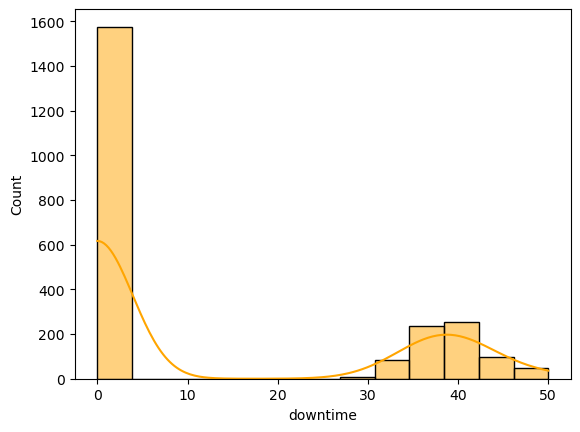

---------- Column Name: EFFICIENCY_SCORE ----------

---------------------------------------------------------------------------------------------------------------------------------------
        Mean     Median    Variance  Standard Deviation      Range
0  15.542868  16.967619  115.899976           10.765685  45.906702
---------------------------------------------------------------------------------------------------------------------------------------


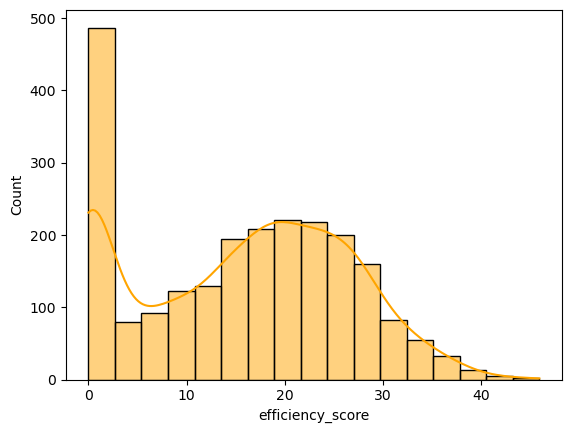

In [168]:
for i in ("temperature", "vibration_level", "power_consumption", "pressure", 
          "material_flow_rate", "cycle_time", "error_rate", "downtime", "efficiency_score"):
    print(f"---------- Column Name: {i.upper()} ----------")
    print("")
    Univariate_Continuous_Data_Analysis(i)
    

In [169]:
def Univariate_categorical_Data_Analysis(col):
    a = pd.DataFrame({
        "Unique Values Count": [df[col].nunique()],
        "Value Count": [df[col].value_counts().sum()]
    })
    
    print(a)
    print("---"*45)

    sns.countplot(x=df[col], color="skyblue")
    plt.show()

---------- Column name: MACHINE_ID ----------
   Unique Values Count  Value Count
0                    4         2303
---------------------------------------------------------------------------------------------------------------------------------------


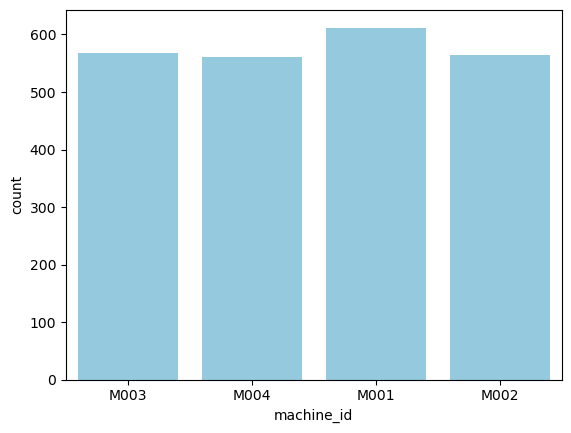

---------- Column name: MACHINE_TYPE ----------
   Unique Values Count  Value Count
0                    4         2303
---------------------------------------------------------------------------------------------------------------------------------------


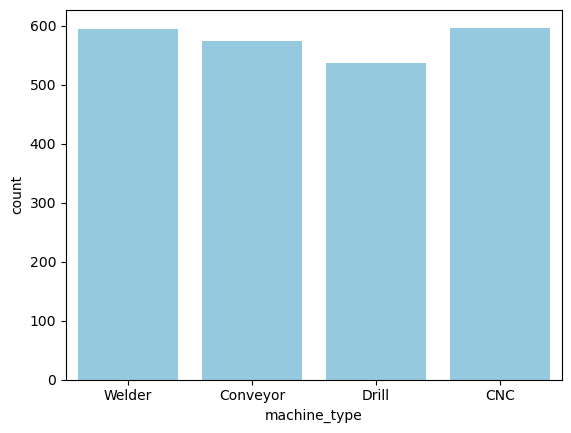

---------- Column name: MAINTENANCE_FLAG ----------
   Unique Values Count  Value Count
0                    2         2303
---------------------------------------------------------------------------------------------------------------------------------------


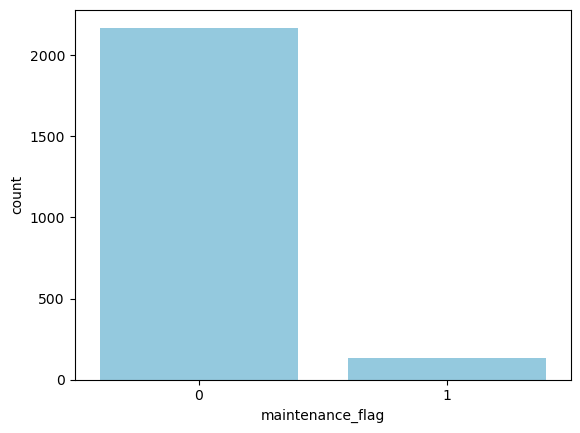

---------- Column name: PRODUCTION_STATUS ----------
   Unique Values Count  Value Count
0                    1         2303
---------------------------------------------------------------------------------------------------------------------------------------


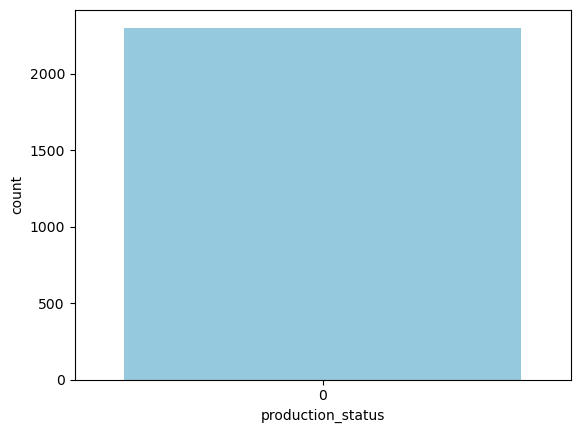

In [170]:
for i in ("machine_id", "machine_type", "maintenance_flag", "production_status"):
    print(f"---------- Column name: {i.upper()} ----------")
    Univariate_categorical_Data_Analysis(i)

## Bivariate Analysis

In [171]:
def bivariate_continuous_analysis(col):
    sns.scatterplot(x=df[col], y=df["efficiency_score"], hue=df["machine_type"], color="black")
    plt.show()

def bivariate_categorical_analysis(col1):
    sns.countplot(x=df[col1], hue=df["machine_type"])
    plt.show()

-------- Doing comparison of TEMPERATURE and Efficiency_Score using scatter plot --------


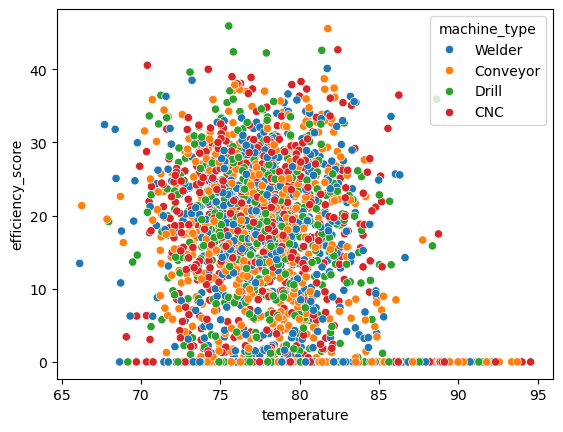

-------- Doing comparison of VIBRATION_LEVEL and Efficiency_Score using scatter plot --------


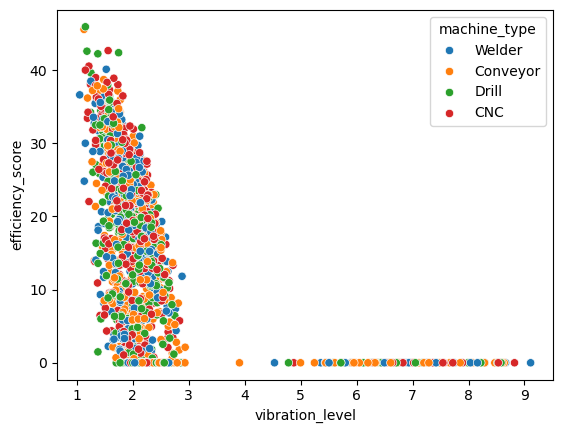

-------- Doing comparison of POWER_CONSUMPTION and Efficiency_Score using scatter plot --------


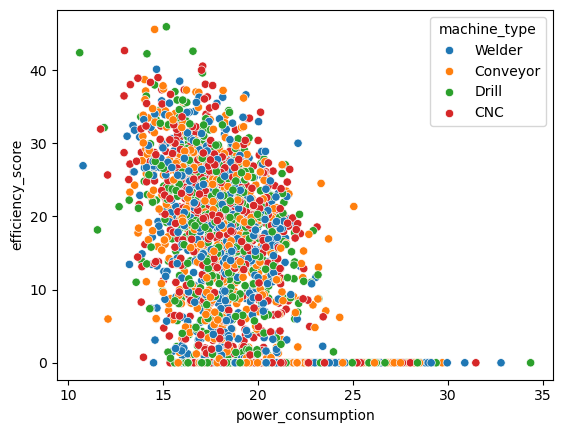

-------- Doing comparison of PRESSURE and Efficiency_Score using scatter plot --------


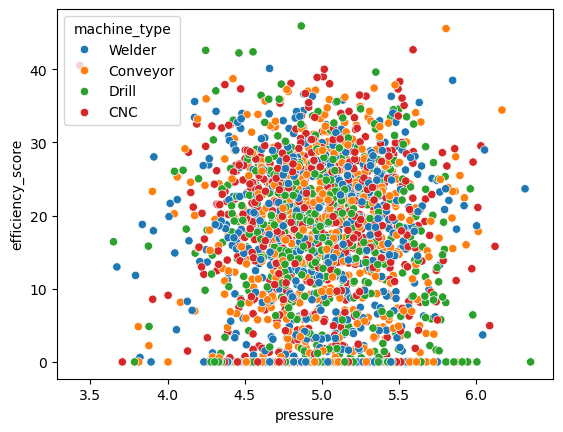

-------- Doing comparison of MATERIAL_FLOW_RATE and Efficiency_Score using scatter plot --------


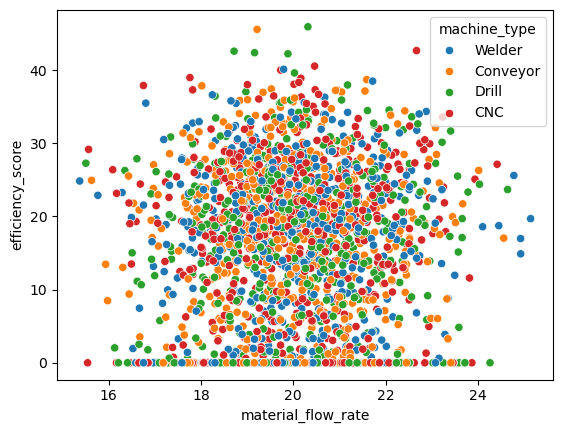

-------- Doing comparison of CYCLE_TIME and Efficiency_Score using scatter plot --------


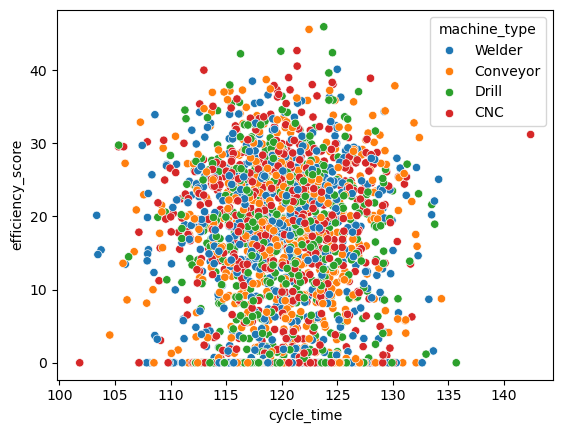

-------- Doing comparison of ERROR_RATE and Efficiency_Score using scatter plot --------


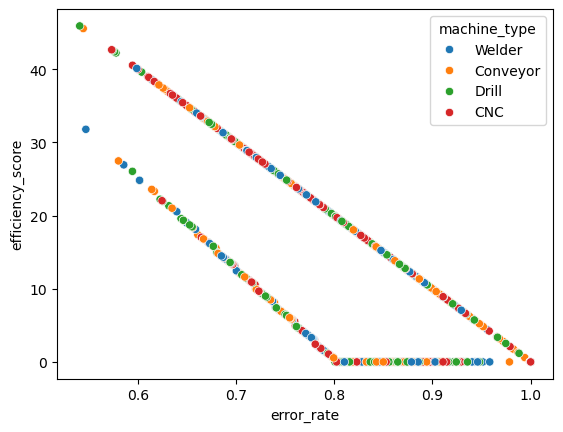

-------- Doing comparison of DOWNTIME and Efficiency_Score using scatter plot --------


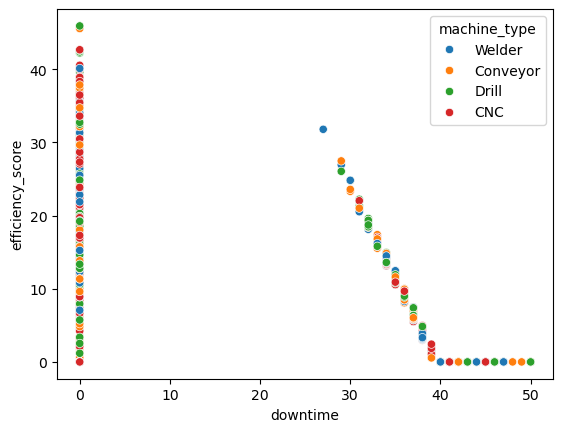

In [172]:
for i in ("temperature", "vibration_level", "power_consumption", "pressure", 
          "material_flow_rate", "cycle_time", "error_rate", "downtime"):
    print(f"-------- Doing comparison of {i.upper()} and Efficiency_Score using scatter plot --------")
    bivariate_continuous_analysis(i)


-------- Doing comparison of MACHINE_ID and Machine type using Count plot --------



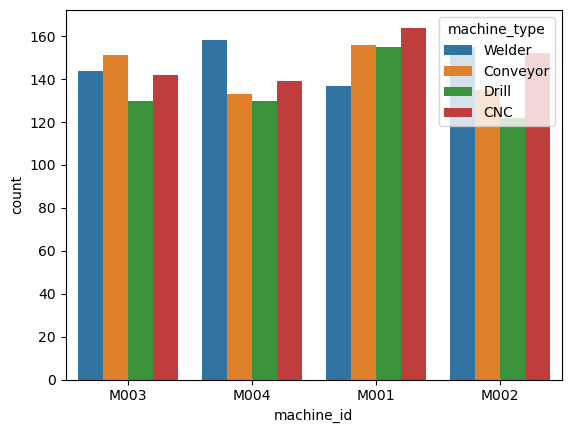


-------- Doing comparison of MAINTENANCE_FLAG and Machine type using Count plot --------



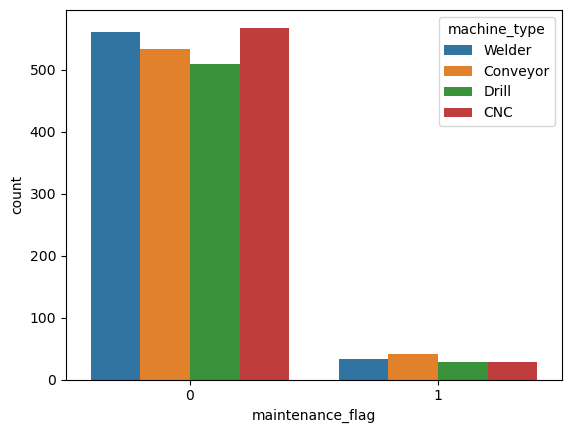


-------- Doing comparison of PRODUCTION_STATUS and Machine type using Count plot --------



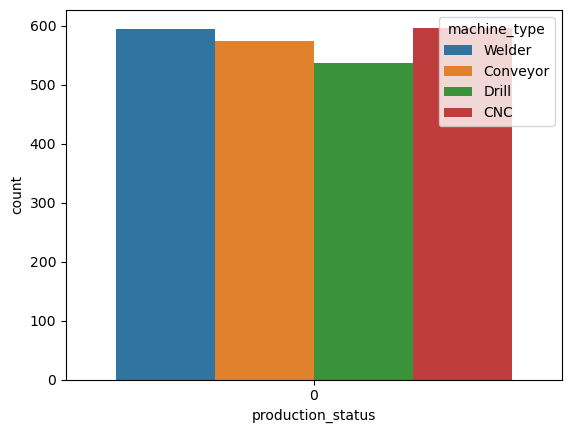

In [173]:
for i in ("machine_id", "maintenance_flag", "production_status"):
    print("")
    print(f"-------- Doing comparison of {i.upper()} and Machine type using Count plot --------")
    print("")
    bivariate_categorical_analysis(i)

## Outliers 

In [174]:
def checking_and_handling_of_outliers(col):
    print(f"Checking and Handling of Outliers for {col}")
    sns.boxplot(df[col], color = "pink")
    plt.show()

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3-q1

    lowertail = q1-1.5*iqr
    uppertail = q3+1.5*iqr

    print("-"*60)
    print(f"LowerTail = {lowertail}")
    print(f"UpperTail = {uppertail}")
    print("-"*60)

    outliers = df[(df[col]<lowertail) | (df[col]>uppertail)]

    if len(outliers) == 0 :
        print("No Outliers")
    else:
        print(outliers)

    # handling of outliers
    df.loc[df[col]<lowertail, col] = lowertail
    df.loc[df[col]>uppertail, col] = uppertail

Checking and Handling of Outliers for temperature


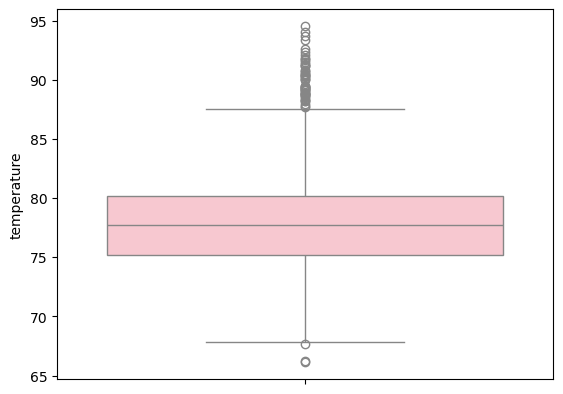

------------------------------------------------------------
LowerTail = 67.8239768079857
UpperTail = 87.54019322820338
------------------------------------------------------------
                timestamp machine_id machine_type  temperature  \
6     2025-03-10 08:06:00       M001       Welder    91.700813   
43    2025-03-10 08:43:00       M004     Conveyor    66.266268   
49    2025-03-10 08:49:00       M002       Welder    89.392208   
59    2025-03-10 08:59:00       M001          CNC    88.304743   
96    2025-03-10 09:36:00       M002       Welder    66.136665   
107   2025-03-10 09:47:00       M004     Conveyor    90.418120   
163   2025-03-10 10:43:00       M004       Welder    87.735532   
190   2025-03-10 11:10:00       M003       Welder    67.699335   
314   2025-03-10 13:14:00       M003       Welder    91.202490   
513   2025-03-10 16:33:00       M002        Drill    90.466939   
594   2025-03-10 17:54:00       M004        Drill    89.302073   
604   2025-03-10 18:04:00  

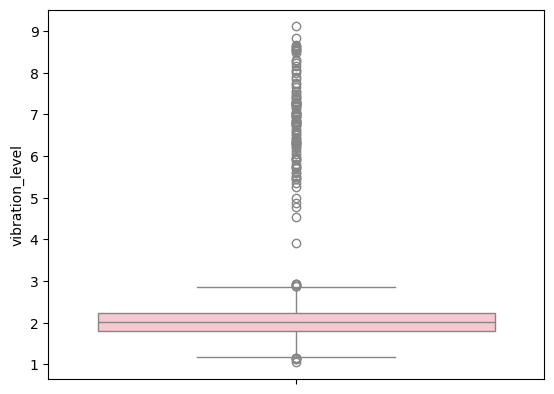

------------------------------------------------------------
LowerTail = 1.163110904648593
UpperTail = 2.8722499382962567
------------------------------------------------------------
                timestamp machine_id machine_type  temperature  \
5     2025-03-10 08:05:00       M004        Drill    86.820317   
6     2025-03-10 08:06:00       M001       Welder    87.540193   
11    2025-03-10 08:11:00       M003     Conveyor    86.600674   
40    2025-03-10 08:40:00       M003     Conveyor    83.945857   
49    2025-03-10 08:49:00       M002       Welder    87.540193   
...                   ...        ...          ...          ...   
2335  2025-03-11 22:55:00       M004     Conveyor    87.540193   
2430  2025-03-12 00:30:00       M004     Conveyor    87.540193   
2431  2025-03-12 00:31:00       M004     Conveyor    87.540193   
2448  2025-03-12 00:48:00       M004       Welder    82.146918   
2459  2025-03-12 00:59:00       M002          CNC    87.540193   

      vibration_level  p

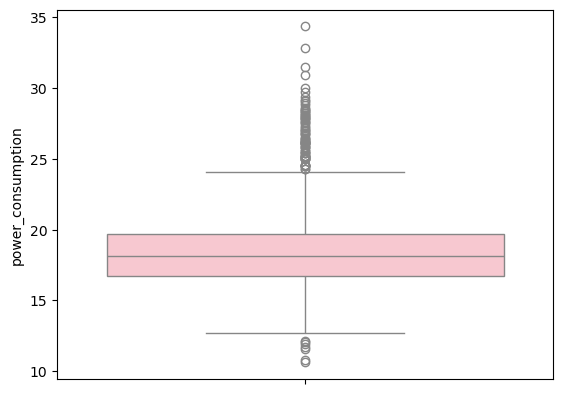

------------------------------------------------------------
LowerTail = 12.299065958012381
UpperTail = 24.141046706004193
------------------------------------------------------------
                timestamp machine_id machine_type  temperature  \
6     2025-03-10 08:06:00       M001       Welder    87.540193   
11    2025-03-10 08:11:00       M003     Conveyor    86.600674   
43    2025-03-10 08:43:00       M004     Conveyor    67.823977   
57    2025-03-10 08:57:00       M001     Conveyor    87.240166   
59    2025-03-10 08:59:00       M001          CNC    87.540193   
...                   ...        ...          ...          ...   
2275  2025-03-11 21:55:00       M001        Drill    87.530268   
2321  2025-03-11 22:41:00       M002     Conveyor    87.119156   
2335  2025-03-11 22:55:00       M004     Conveyor    87.540193   
2430  2025-03-12 00:30:00       M004     Conveyor    87.540193   
2431  2025-03-12 00:31:00       M004     Conveyor    87.540193   

      vibration_level  

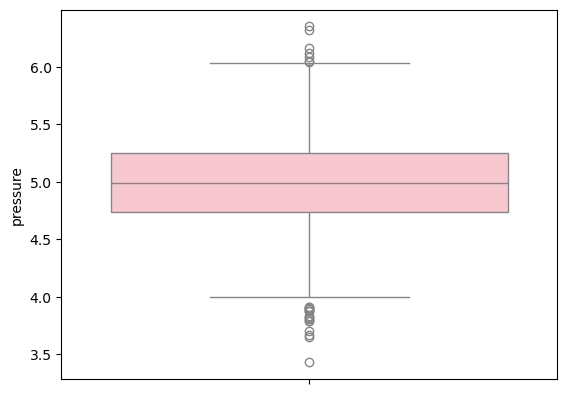

------------------------------------------------------------
LowerTail = 3.9538349695095847
UpperTail = 6.0344100784684915
------------------------------------------------------------
                timestamp machine_id machine_type  temperature  \
265   2025-03-10 12:25:00       M002     Conveyor    71.449315   
298   2025-03-10 12:58:00       M001     Conveyor    79.864746   
462   2025-03-10 15:42:00       M002          CNC    70.400843   
819   2025-03-10 21:39:00       M001       Welder    73.212269   
877   2025-03-10 22:37:00       M002     Conveyor    71.454506   
909   2025-03-10 23:09:00       M002          CNC    81.726189   
1149  2025-03-11 03:09:00       M001       Welder    78.995436   
1235  2025-03-11 04:35:00       M004        Drill    75.427382   
1273  2025-03-11 05:13:00       M003          CNC    78.864785   
1427  2025-03-11 07:47:00       M003          CNC    77.404692   
1458  2025-03-11 08:18:00       M002       Welder    75.515968   
1652  2025-03-11 11:32:0

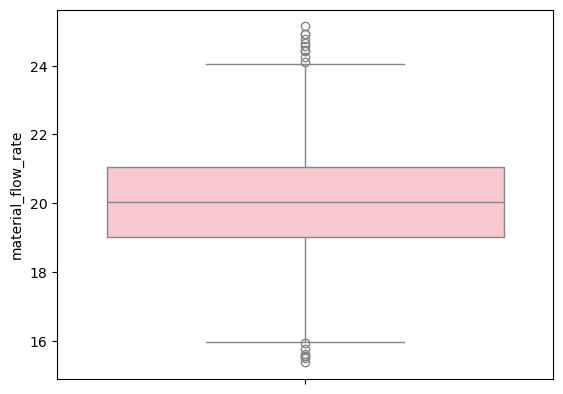

------------------------------------------------------------
LowerTail = 15.960263231834316
UpperTail = 24.100031167755944
------------------------------------------------------------
                timestamp machine_id machine_type  temperature  \
185   2025-03-10 11:05:00       M001        Drill    72.369607   
201   2025-03-10 11:21:00       M004     Conveyor    77.563260   
477   2025-03-10 15:57:00       M004          CNC    79.991290   
825   2025-03-10 21:45:00       M004       Welder    76.224998   
940   2025-03-10 23:40:00       M004       Welder    78.515798   
1145  2025-03-11 03:05:00       M002        Drill    82.223753   
1401  2025-03-11 07:21:00       M003     Conveyor    80.352973   
1438  2025-03-11 07:58:00       M004        Drill    76.346314   
1457  2025-03-11 08:17:00       M004       Welder    76.270744   
1668  2025-03-11 11:48:00       M003       Welder    75.471486   
1676  2025-03-11 11:56:00       M003       Welder    80.754279   
1772  2025-03-11 13:32:0

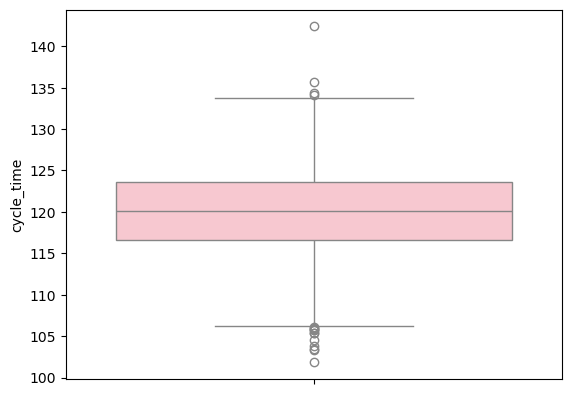

------------------------------------------------------------
LowerTail = 106.13505198854564
UpperTail = 134.03328549732288
------------------------------------------------------------
                timestamp machine_id machine_type  temperature  \
96    2025-03-10 09:36:00       M002       Welder    67.823977   
353   2025-03-10 13:53:00       M004       Welder    73.685077   
426   2025-03-10 15:06:00       M001       Welder    79.502038   
487   2025-03-10 16:07:00       M004     Conveyor    76.804726   
684   2025-03-10 19:24:00       M001        Drill    75.786335   
755   2025-03-10 20:35:00       M002       Welder    78.730789   
934   2025-03-10 23:34:00       M004          CNC    73.592270   
1047  2025-03-11 01:27:00       M001          CNC    77.446176   
1080  2025-03-11 02:00:00       M003     Conveyor    80.444088   
1259  2025-03-11 04:59:00       M003     Conveyor    80.241077   
1324  2025-03-11 06:04:00       M001     Conveyor    79.608132   
1330  2025-03-11 06:10:0

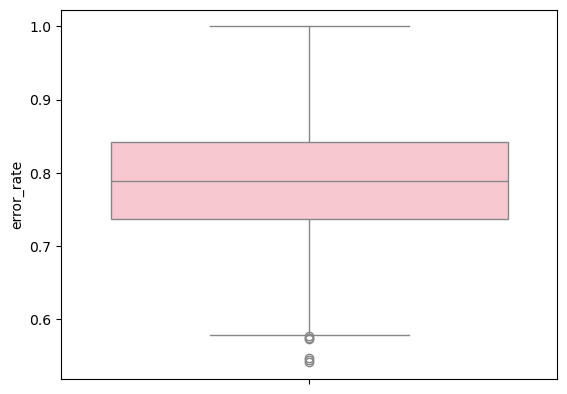

------------------------------------------------------------
LowerTail = 0.5778237173972981
UpperTail = 1.000438319560366
------------------------------------------------------------
                timestamp machine_id machine_type  temperature  \
247   2025-03-10 12:07:00       M001     Conveyor    81.770853   
251   2025-03-10 12:11:00       M001        Drill    75.530770   
628   2025-03-10 18:28:00       M003       Welder    68.369699   
763   2025-03-10 20:43:00       M002        Drill    75.819202   
1199  2025-03-11 03:59:00       M001        Drill    81.392890   
1760  2025-03-11 13:20:00       M004          CNC    82.404863   

      vibration_level  power_consumption  pressure  material_flow_rate  \
247          1.163111          14.567934  5.803389           19.218118   
251          1.163111          15.185826  4.865689           20.319089   
628          1.368575          13.508828  5.124825           22.676838   
763          1.744333          12.299066  4.553420        

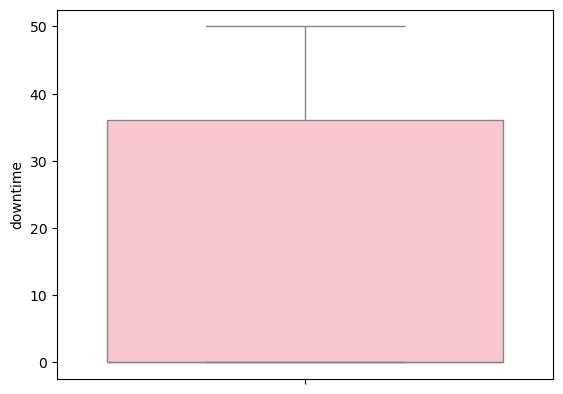

------------------------------------------------------------
LowerTail = -54.0
UpperTail = 90.0
------------------------------------------------------------
No Outliers
Checking and Handling of Outliers for efficiency_score


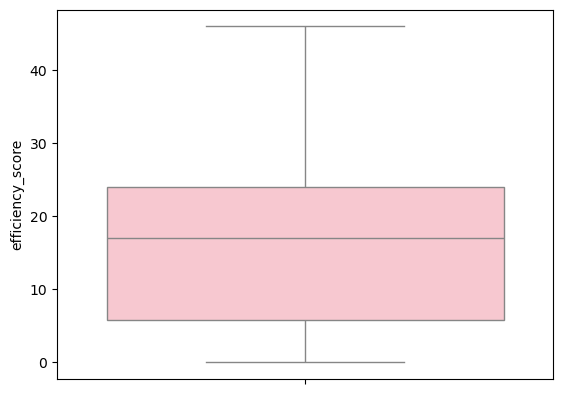

------------------------------------------------------------
LowerTail = -21.64712257950271
UpperTail = 51.353191196607014
------------------------------------------------------------
No Outliers


In [175]:
for i in ("temperature", "vibration_level", "power_consumption", "pressure", "material_flow_rate", "cycle_time", "error_rate", "downtime",
        "efficiency_score"):
    checking_and_handling_of_outliers(i)

## Encoding

In [176]:
df

,timestamp,machine_id,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score,production_status
0,2025-03-10 08:00:00,M003,Welder,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0,11.675410,0
1,2025-03-10 08:01:00,M004,Conveyor,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0,3.292706,0
2,2025-03-10 08:02:00,M001,Drill,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0,5.762582,0
3,2025-03-10 08:03:00,M003,Conveyor,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0,0.851911,0
4,2025-03-10 08:04:00,M003,CNC,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0,18.663902,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2455,2025-03-12 00:55:00,M001,Conveyor,80.585617,1.744735,14.463169,5.034138,20.826884,113.009590,0.652834,0,0,34.716573,0
2456,2025-03-12 00:56:00,M003,Drill,78.171483,2.732367,19.990335,4.971981,18.291071,132.987186,0.988201,0,0,1.179945,0
2457,2025-03-12 00:57:00,M003,Welder,78.782847,2.131138,19.874735,5.290168,22.551457,114.350925,0.847650,0,0,15.234984,0
2458,2025-03-12 00:58:00,M001,Drill,77.939129,2.027617,19.660323,4.924919,22.706616,117.406875,0.807874,0,0,19.212551,0


In [177]:
df = df.drop(["timestamp", "production_status"], axis=1)

In [178]:
df

,machine_id,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score
0,M003,Welder,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0,11.675410
1,M004,Conveyor,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0,3.292706
2,M001,Drill,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0,5.762582
3,M003,Conveyor,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0,0.851911
4,M003,CNC,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0,18.663902
...,...,...,...,...,...,...,...,...,...,...,...,...
2455,M001,Conveyor,80.585617,1.744735,14.463169,5.034138,20.826884,113.009590,0.652834,0,0,34.716573
2456,M003,Drill,78.171483,2.732367,19.990335,4.971981,18.291071,132.987186,0.988201,0,0,1.179945
2457,M003,Welder,78.782847,2.131138,19.874735,5.290168,22.551457,114.350925,0.847650,0,0,15.234984
2458,M001,Drill,77.939129,2.027617,19.660323,4.924919,22.706616,117.406875,0.807874,0,0,19.212551


In [179]:
le = LabelEncoder()
le_array = le.fit_transform(df["machine_id"])
df["machine_id"] = pd.DataFrame(le_array).values
df.head(10)

,machine_id,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score
0,2,Welder,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0,11.675410
1,3,Conveyor,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0,3.292706
2,0,Drill,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0,5.762582
3,2,Conveyor,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0,0.851911
4,2,CNC,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0,18.663902
5,3,Drill,86.820317,2.872250,20.040572,4.965513,20.700636,121.528506,1.000000,0,1,0.000000
6,0,Welder,87.540193,2.872250,24.141047,4.948131,21.954393,122.757183,1.000000,0,1,0.000000
7,0,CNC,70.505322,1.592745,21.387094,4.385388,19.002452,123.629106,0.780886,0,0,21.911376
8,2,CNC,75.777486,1.729799,18.302815,4.886084,17.853329,121.746464,0.718756,0,0,28.124433
9,1,Welder,76.421380,1.710740,17.414629,4.601094,19.894955,118.644424,0.717481,0,0,28.251852


In [180]:
le = LabelEncoder()
le_array = le.fit_transform(df["machine_type"])
df["machine_type"] = pd.DataFrame(le_array).values
df

,machine_id,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score
0,2,3,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0,11.675410
1,3,1,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0,3.292706
2,0,2,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0,5.762582
3,2,1,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0,0.851911
4,2,0,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0,18.663902
...,...,...,...,...,...,...,...,...,...,...,...,...
2455,0,1,80.585617,1.744735,14.463169,5.034138,20.826884,113.009590,0.652834,0,0,34.716573
2456,2,2,78.171483,2.732367,19.990335,4.971981,18.291071,132.987186,0.988201,0,0,1.179945
2457,2,3,78.782847,2.131138,19.874735,5.290168,22.551457,114.350925,0.847650,0,0,15.234984
2458,0,2,77.939129,2.027617,19.660323,4.924919,22.706616,117.406875,0.807874,0,0,19.212551


In [181]:
df.isna().sum()

machine_id            0
machine_type          0
temperature           0
vibration_level       0
power_consumption     0
pressure              0
material_flow_rate    0
cycle_time            0
error_rate            0
downtime              0
maintenance_flag      0
efficiency_score      0
dtype: int64

## Feature Extraction

In [182]:
x = df.drop(columns=["machine_id", "efficiency_score"], axis=1)
y = df["efficiency_score"]

In [183]:
x

,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag
0,3,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0
1,1,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0
2,2,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0
3,1,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0
4,0,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0
...,...,...,...,...,...,...,...,...,...,...
2455,1,80.585617,1.744735,14.463169,5.034138,20.826884,113.009590,0.652834,0,0
2456,2,78.171483,2.732367,19.990335,4.971981,18.291071,132.987186,0.988201,0,0
2457,3,78.782847,2.131138,19.874735,5.290168,22.551457,114.350925,0.847650,0,0
2458,2,77.939129,2.027617,19.660323,4.924919,22.706616,117.406875,0.807874,0,0


## Scaling

In [184]:
b = StandardScaler()
c = b.fit_transform(x)
scale = pd.DataFrame(c, columns=x.columns, index=x.index)
print(scale)

      machine_type  temperature  vibration_level  power_consumption  pressure  \
0         1.332660     0.117886         0.029050           2.031993  0.240220   
1        -0.432214     0.805950         0.407303          -0.987999  1.079545   
2         0.450223    -1.749811         0.346695          -1.096700  2.000430   
3        -0.432214    -0.365027         0.609249          -0.783388 -0.972192   
4        -1.314651    -1.135898         0.182691          -0.108846  1.126808   
...            ...          ...              ...                ...       ...   
2455     -0.432214     0.728045        -0.828843          -1.652096  0.100871   
2456      0.450223     0.082765         2.004725           0.716558 -0.059709   
2457      1.332660     0.246178         0.279768           0.667017  0.762322   
2458      0.450223     0.020658        -0.017240           0.575132 -0.181293   
2459     -1.314651     2.586952         2.406058           2.226824 -1.060748   

      material_flow_rate  c

## Train Test Split

In [185]:
trainx, testx, trainy, testy = train_test_split(x,y, test_size=0.2, random_state=42)


## Multivariate Analysis

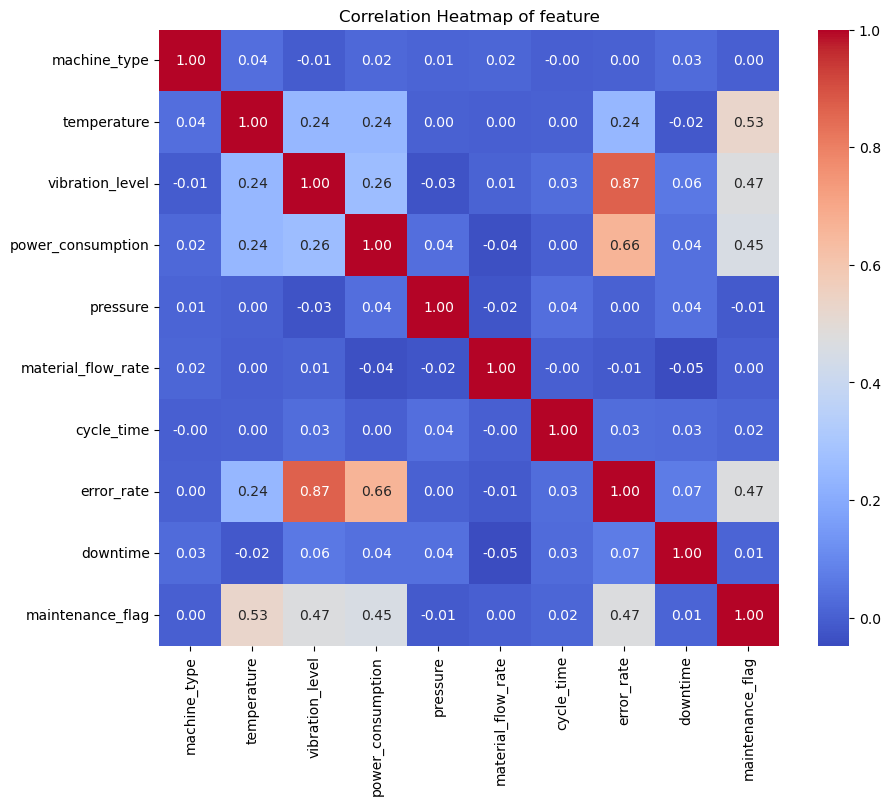

In [186]:
plt.figure(figsize=(10,8))
sns.heatmap(trainx.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of feature")
plt.show()

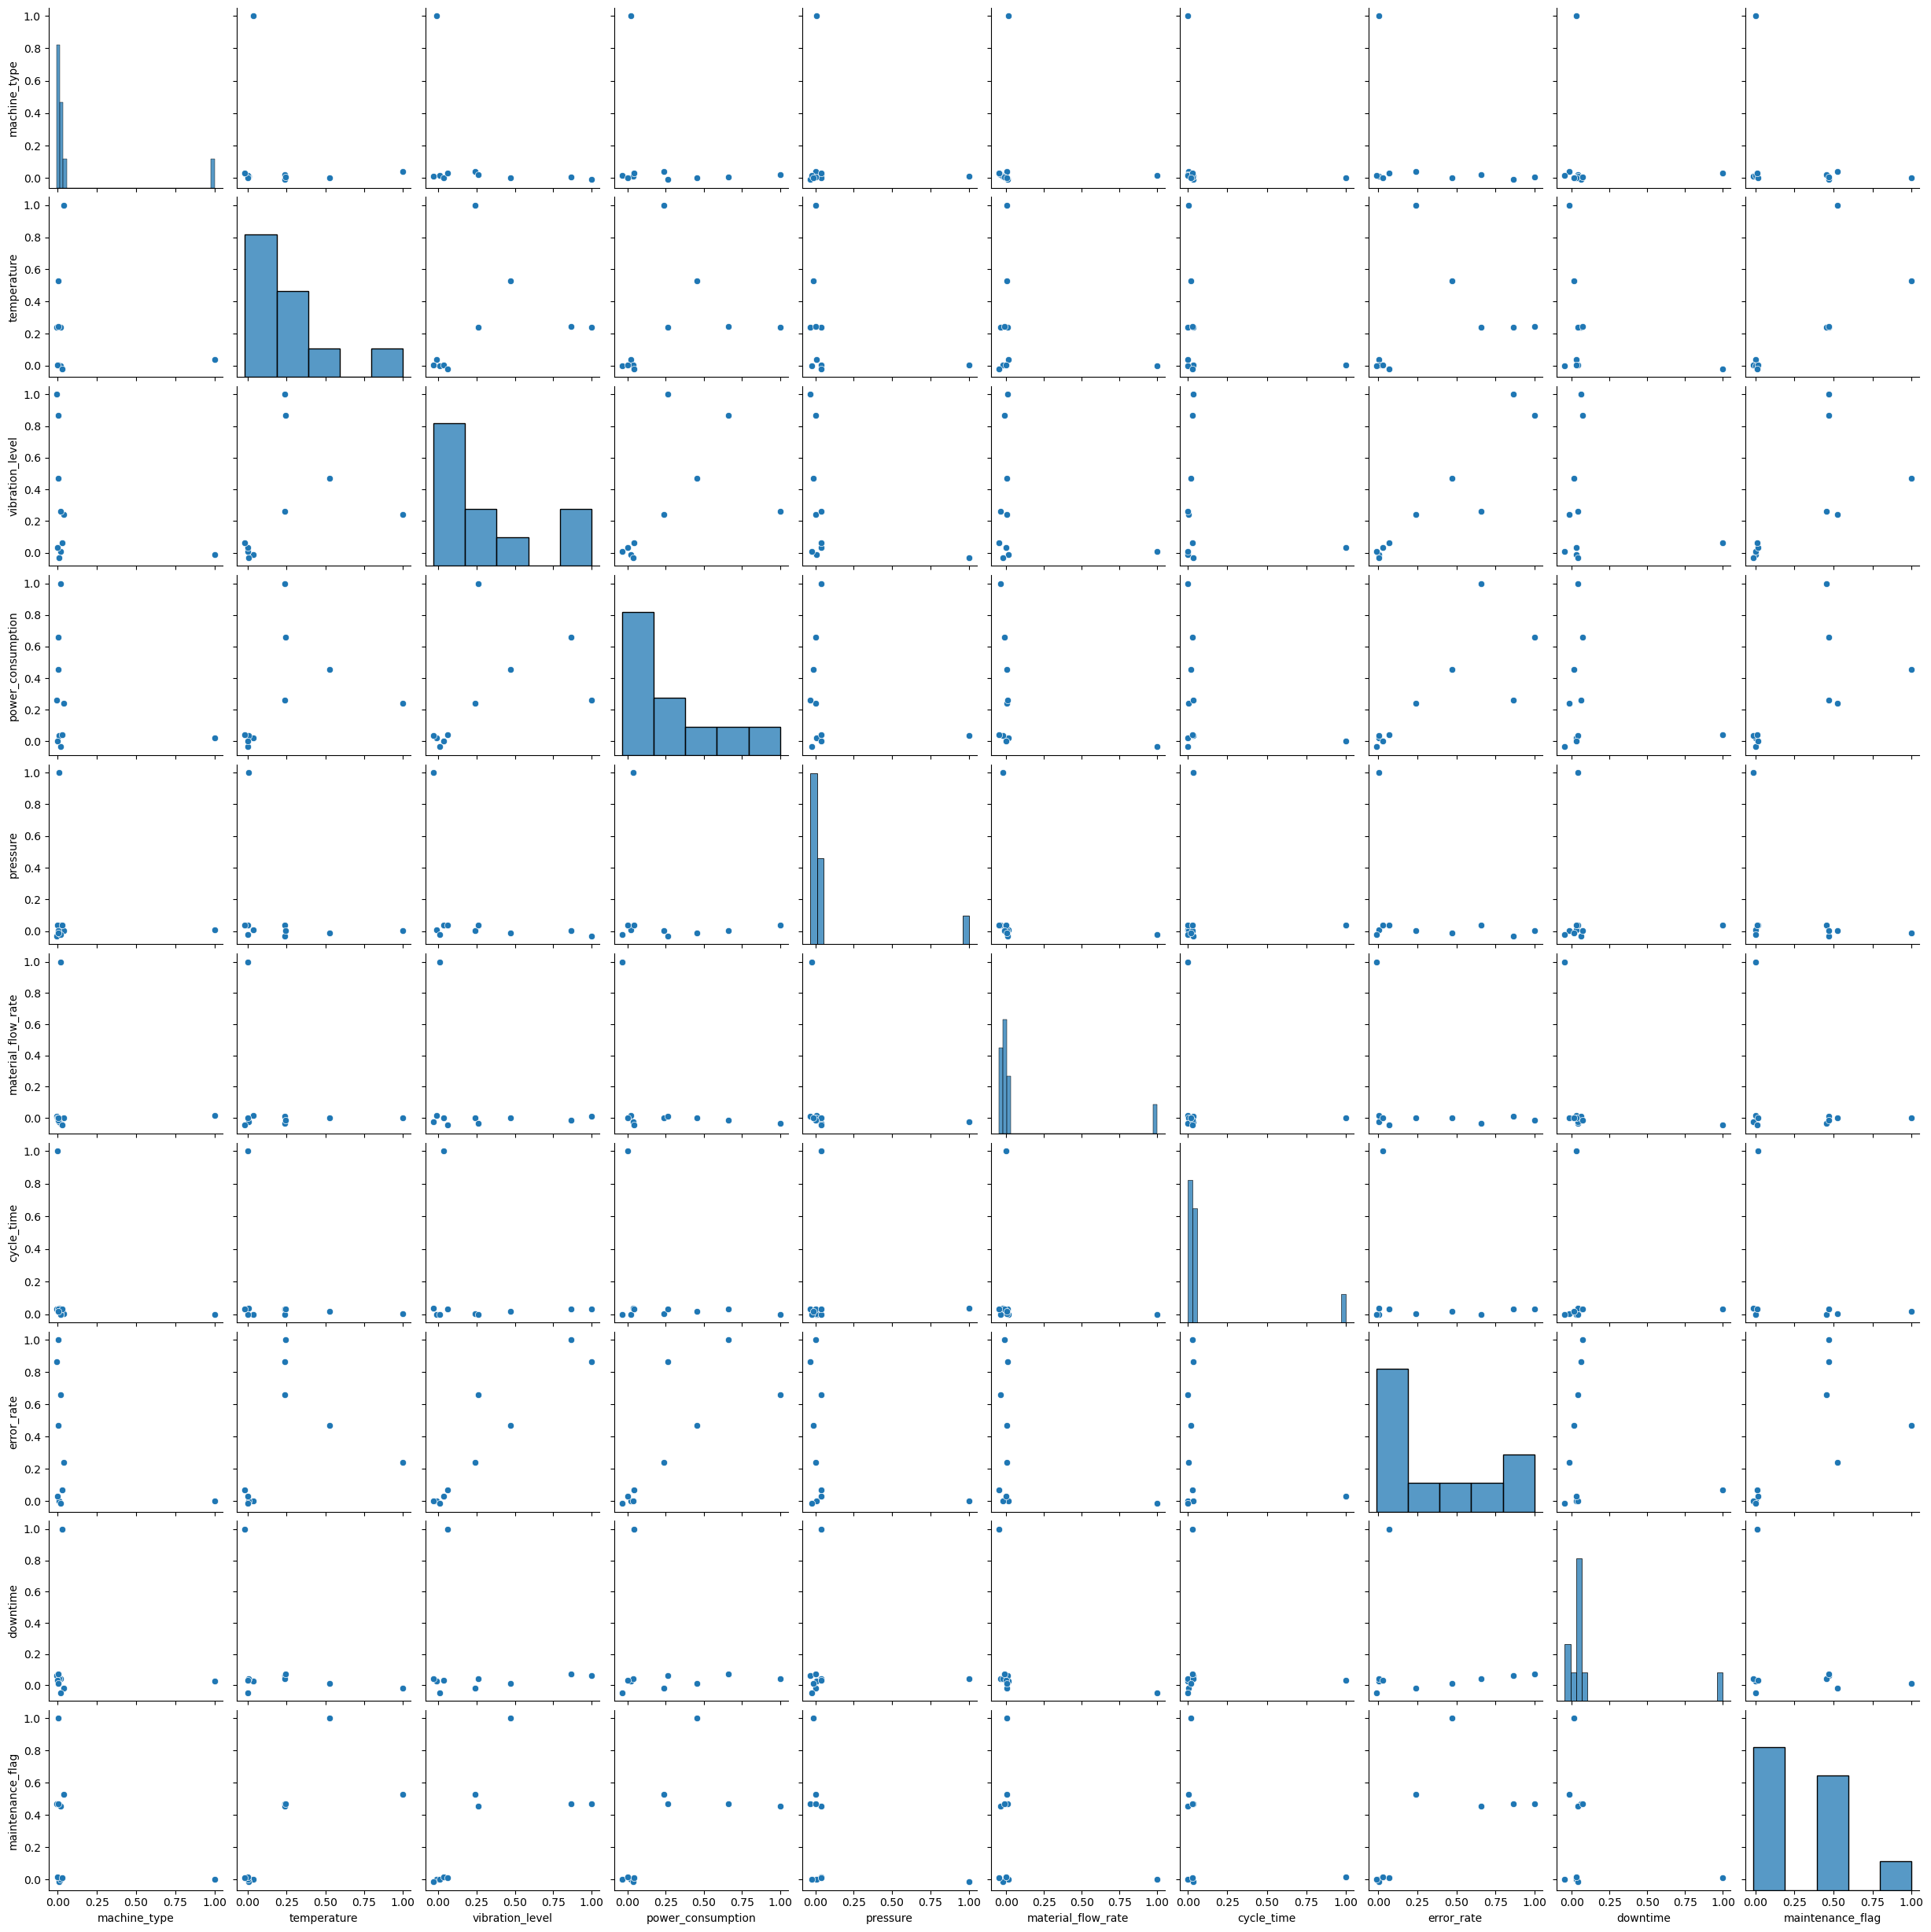

In [187]:
sns.pairplot(trainx.corr())

## Assumption 1 - Linearity

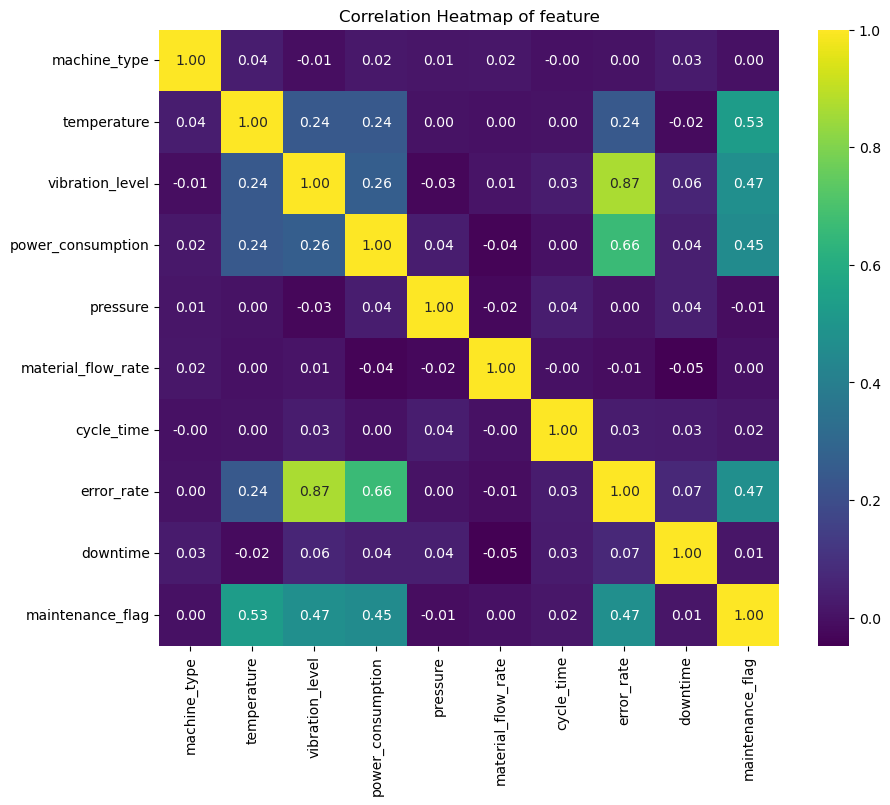

In [188]:
plt.figure(figsize=(10,8))
sns.heatmap(trainx.corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap of feature")
plt.show()

## Assumption 2 - Independance

In [189]:
x

,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag
0,3,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0
1,1,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0
2,2,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0
3,1,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0
4,0,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0
...,...,...,...,...,...,...,...,...,...,...
2455,1,80.585617,1.744735,14.463169,5.034138,20.826884,113.009590,0.652834,0,0
2456,2,78.171483,2.732367,19.990335,4.971981,18.291071,132.987186,0.988201,0,0
2457,3,78.782847,2.131138,19.874735,5.290168,22.551457,114.350925,0.847650,0,0
2458,2,77.939129,2.027617,19.660323,4.924919,22.706616,117.406875,0.807874,0,0


In [190]:
a = pd.DataFrame()
a["Independent Feature"] = x.columns
a

,Independent Feature
0,machine_type
1,temperature
2,vibration_level
3,power_consumption
4,pressure
5,material_flow_rate
6,cycle_time
7,error_rate
8,downtime
9,maintenance_flag


In [191]:
a.shape[0]

10

In [192]:
p = []

for i in range(a.shape[0]):
    vif = variance_inflation_factor(x.to_numpy(), i)
    p.append(vif)


a["VIF"] = p
a

,Independent Feature,VIF
0,machine_type,2.735680
1,temperature,388.122606
2,vibration_level,652.529949
3,power_consumption,534.227158
4,pressure,153.775352
5,material_flow_rate,156.594423
6,cycle_time,376.627724
7,error_rate,2433.939644
8,downtime,1.468795
9,maintenance_flag,2.341557


## Model Training and Evaluation
### Algorithm 1 : Linear Regression

In [193]:
lin_reg = LinearRegression()
lin_reg

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [194]:
lin_reg_model = lin_reg.fit(trainx, trainy)
lin_reg_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [195]:
ytrain_pred = lin_reg_model.predict(trainx)
ytest_pred = lin_reg_model.predict(testx)

In [196]:
error = trainy - ytrain_pred
error

1854    0.087551
378     1.780434
2318   -1.807970
369    -1.654838
1522    0.168795
          ...   
1749    0.294297
1167    1.028796
1205   -3.462358
1385    1.608182
907     0.354533
Name: efficiency_score, Length: 1842, dtype: float64

## Assumption 3 - Normality of residual

<Axes: xlabel='efficiency_score', ylabel='Density'>

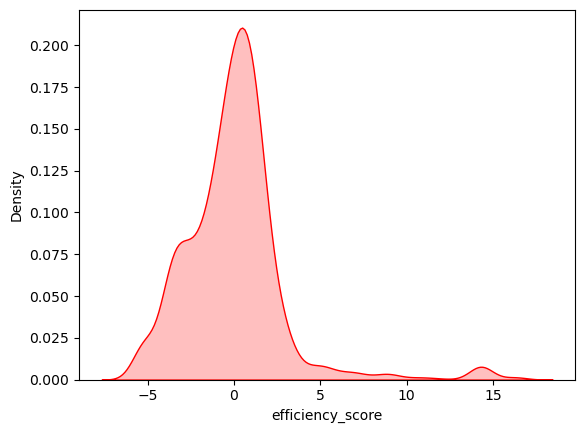

In [197]:
sns.kdeplot(error, fill = True, color = "red")

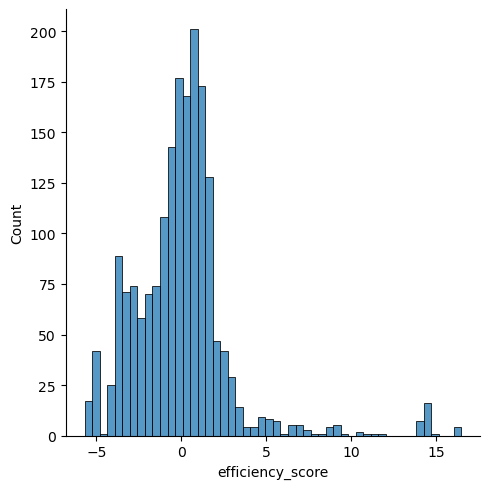

In [198]:
sns.displot(error)

In [199]:
stats, pval = shapiro(error)

if pval > 0.05:
    print("Null Hypothesis(H0) is True")
    print("error is normally distributed")
else:
    print("Alternative Hypothesis(H1) is True")
    print("error is not normally distributed")

Alternative Hypothesis(H1) is True
error is not normally distributed


##  Assummption 4 - Homoscadasticity (after model training)

<Axes: xlabel='efficiency_score', ylabel='efficiency_score'>

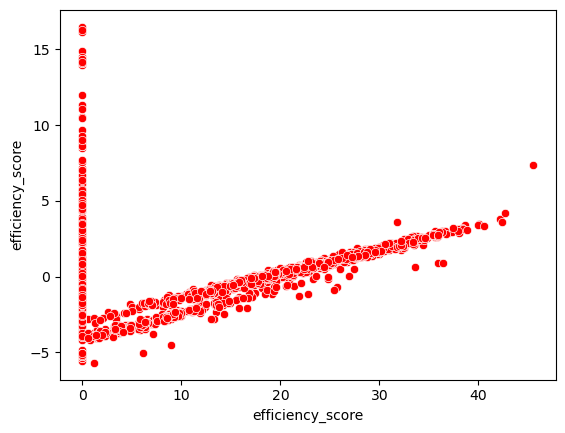

In [200]:
sns.scatterplot(x=trainy, y=error, color="red")

In [201]:
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(trainy, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(trainy, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(trainy, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 8.704298729671265
--------------------------------------------------
Mean Absolute Error = 1.9226827297696096
--------------------------------------------------
Root Mean Squared Error = 2.9503048536839827
--------------------------------------------------
R2 Score = 0.9233738081365163
--------------------------------------------------


In [202]:
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(testy, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(testy, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(testy, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 10.710975796095223
--------------------------------------------------
Mean Absolute Error = 2.074846306567976
--------------------------------------------------
Root Mean Squared Error = 3.272762716130704
--------------------------------------------------
R2 Score = 0.9142161522089592
--------------------------------------------------


## Model Training and Evaluation
### Algorithm 2: KNN Regression

In [203]:
knn = KNeighborsRegressor()
knn_model = knn.fit(trainx, trainy)
knn_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [204]:
ytrain_pred = knn_model.predict(trainx)
ytest_pred = knn_model.predict(testx)

In [205]:
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(trainy, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(trainy, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(trainy, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 18.905372697200093
--------------------------------------------------
Mean Absolute Error = 3.02545069375435
--------------------------------------------------
Root Mean Squared Error = 4.3480308988322625
--------------------------------------------------
R2 Score = 0.8335711169231628
--------------------------------------------------


In [206]:
# model evaluation for training data

print("Model Evaluation for Testing Data")
print("-"* 50)
mse = mean_squared_error(testy, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(testy, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(testy, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 28.924637643741686
--------------------------------------------------
Mean Absolute Error = 3.6965163064303246
--------------------------------------------------
Root Mean Squared Error = 5.378163036180819
--------------------------------------------------
R2 Score = 0.768343542149884
--------------------------------------------------


## Model Training and Evaluation
### Algorithm 3: Decission Tree

In [207]:
dt = DecisionTreeRegressor()
dt_model = dt.fit(trainx, trainy)
dt_model

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [208]:
ytrain_pred = dt_model.predict(trainx)
ytest_pred = dt_model.predict(testx)

In [209]:
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(trainy, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(trainy, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(trainy, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 0.0
--------------------------------------------------
Mean Absolute Error = 0.0
--------------------------------------------------
Root Mean Squared Error = 0.0
--------------------------------------------------
R2 Score = 1.0
--------------------------------------------------


In [210]:
# model evaluation for training data

print("Model Evaluation for Testing Data")
print("-"* 50)
mse = mean_squared_error(testy, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(testy, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(testy, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 0.027152892644307466
--------------------------------------------------
Mean Absolute Error = 0.047176536668091365
--------------------------------------------------
Root Mean Squared Error = 0.16478134798668043
--------------------------------------------------
R2 Score = 0.999782533388738
--------------------------------------------------


## Model Training and Evaluation
### Algorithm 4: Random Forest

In [211]:
rm = RandomForestRegressor()
rm_model = rm.fit(trainx, trainy)
rm_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [212]:
ytrain_pred = rm_model.predict(trainx)
ytest_pred = rm_model.predict(testx)

In [213]:
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(trainy, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(trainy, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(trainy, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 0.0051228862999795535
--------------------------------------------------
Mean Absolute Error = 0.014239998014860705
--------------------------------------------------
Root Mean Squared Error = 0.0715743410726187
--------------------------------------------------
R2 Score = 0.9999549019075852
--------------------------------------------------


In [214]:
# model evaluation for training data

print("Model Evaluation for Testing Data")
print("-"* 50)
mse = mean_squared_error(testy, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(testy, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(testy, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 0.0377600847730959
--------------------------------------------------
Mean Absolute Error = 0.03486165729098096
--------------------------------------------------
Root Mean Squared Error = 0.1943195429520559
--------------------------------------------------
R2 Score = 0.9996975807408758
--------------------------------------------------


## Model Training and Evaluation
### Algorithm 5: Adaboost Regression

In [215]:
adb = AdaBoostRegressor()
adb_model = adb.fit(trainx, trainy)
adb_model

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [216]:
ytrain_pred = adb_model.predict(trainx)
ytest_pred = adb_model.predict(testx)

In [217]:
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(trainy, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(trainy, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(trainy, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 1.36275952445601
--------------------------------------------------
Mean Absolute Error = 0.9657409478091151
--------------------------------------------------
Root Mean Squared Error = 1.1673729157625725
--------------------------------------------------
R2 Score = 0.9880032756195742
--------------------------------------------------


In [218]:
# model evaluation for Testing data

print("Model Evaluation for Testing Data")
print("-"* 50)
mse = mean_squared_error(testy, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(testy, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(testy, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 1.5084299331911446
--------------------------------------------------
Mean Absolute Error = 0.9997169729595694
--------------------------------------------------
Root Mean Squared Error = 1.2281815554677349
--------------------------------------------------
R2 Score = 0.987919034992172
--------------------------------------------------


## Model Training and Evaluation
### Algorithm 6: Gradiant boost Regression

In [219]:
gdb = GradientBoostingRegressor()
gdb_model = gdb.fit(trainx, trainy)
gdb_model

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [220]:
ytrain_pred = gdb_model.predict(trainx)
ytest_pred = gdb_model.predict(testx)

In [221]:
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(trainy, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(trainy, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(trainy, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 0.02189089437360112
--------------------------------------------------
Mean Absolute Error = 0.10079675376269794
--------------------------------------------------
Root Mean Squared Error = 0.1479557176103753
--------------------------------------------------
R2 Score = 0.9998072887978193
--------------------------------------------------


In [222]:
# model evaluation for Testing data

print("Model Evaluation for Testing Data")
print("-"* 50)
mse = mean_squared_error(testy, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(testy, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(testy, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 0.04729170023759027
--------------------------------------------------
Mean Absolute Error = 0.13216075095278296
--------------------------------------------------
Root Mean Squared Error = 0.21746654969808638
--------------------------------------------------
R2 Score = 0.9996212423506325
--------------------------------------------------


## Model Training and Evaluation
### Algorithm 7: XGboost Regression

In [223]:
xgb = XGBRegressor()
xgb_model = xgb.fit(trainx, trainy)
xgb_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [224]:
ytrain_pred = xgb_model.predict(trainx)
ytest_pred = xgb_model.predict(testx)

In [225]:
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(trainy, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(trainy, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(trainy, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 0.00027217145904812377
--------------------------------------------------
Mean Absolute Error = 0.0116081605541582
--------------------------------------------------
Root Mean Squared Error = 0.016497619799477857
--------------------------------------------------
R2 Score = 0.999997604004287
--------------------------------------------------


In [226]:
# model evaluation for Testing data

print("Model Evaluation for Testing Data")
print("-"* 50)
mse = mean_squared_error(testy, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(testy, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(testy, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 0.09698365354134454
--------------------------------------------------
Mean Absolute Error = 0.10211817760715443
--------------------------------------------------
Root Mean Squared Error = 0.31142198628443774
--------------------------------------------------
R2 Score = 0.99922326115454
--------------------------------------------------


## Model Training and Evaluation
### Algorithm 8: Support Vector Machine (SVM)

In [227]:
svm = SVR()
svm_model = svm.fit(trainx, trainy)
svm_model

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [228]:
ytrain_pred = svm_model.predict(trainx)
ytest_pred = svm_model.predict(testx)

In [229]:
# model evaluation for training data

print("Model Evaluation for Training Data")
print("-"* 50)
mse = mean_squared_error(trainy, ytrain_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(trainy, ytrain_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(trainy, ytrain_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Mean Squared Error = 50.42459005368118
--------------------------------------------------
Mean Absolute Error = 5.307533429877049
--------------------------------------------------
Root Mean Squared Error = 7.101027394235371
--------------------------------------------------
R2 Score = 0.5560992985087021
--------------------------------------------------


In [230]:
# model evaluation for Testing data

print("Model Evaluation for Testing Data")
print("-"* 50)
mse = mean_squared_error(testy, ytest_pred)
print(f"Mean Squared Error = {mse}")
print("-"* 50)

mae = mean_absolute_error(testy, ytest_pred)
print(f"Mean Absolute Error = {mae}")
print("-"* 50)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error = {rmse}")
print("-"* 50)

r2 = r2_score(testy, ytest_pred)
print(f"R2 Score = {r2}")
print("-"* 50)

Model Evaluation for Testing Data
--------------------------------------------------
Mean Squared Error = 54.60635410745957
--------------------------------------------------
Mean Absolute Error = 5.56295509374711
--------------------------------------------------
Root Mean Squared Error = 7.389611228438176
--------------------------------------------------
R2 Score = 0.5626595318340927
--------------------------------------------------


In [235]:
filename = "Production_System_ML_Model(R).pkl"

with open(filename, "wb") as file:
    pickle.dump(rm_model, file)

print(f"Best Fit Model Saved to {filename}")

Best Fit Model Saved to Production_System_ML_Model(R).pkl


In [236]:
with open(filename, "rb") as file:
    FinalModel = pickle.load(file)

FinalModel

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [237]:
import streamlit as st

In [ ]:
st.set_page_config